In [1]:
import numpy as np
import pandas as pd
from google.colab import files
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_absolute_error, mean_squared_error
from scipy.optimize import minimize

## Time Series Model with PM2.5 air quality data


In [2]:
uploaded = files.upload()

Saving air_pollution.csv to air_pollution (5).csv


In [3]:
# read data
air_pollution_df = pd.read_csv('air_pollution.csv')
air_pollution_df.head()

,Unnamed: 0,Date,Value,location,parameter,longitude,latitude,Data_Converted
0,0,2024-08-22T13:00:00+00:00,0.837500,1552754,pm25,-122.432269,45.592266,2024-08-22 13:00:00+00:00
1,1,2024-08-22T12:00:00+00:00,0.691667,1552754,pm25,-122.432269,45.592266,2024-08-22 12:00:00+00:00
2,2,2024-08-22T11:00:00+00:00,0.889583,1552754,pm25,-122.432269,45.592266,2024-08-22 11:00:00+00:00
3,3,2024-08-22T10:00:00+00:00,0.697917,1552754,pm25,-122.432269,45.592266,2024-08-22 10:00:00+00:00
4,4,2024-08-22T09:00:00+00:00,0.681250,1552754,pm25,-122.432269,45.592266,2024-08-22 09:00:00+00:00


In [4]:
# extract Northwest Portland, Oregan as target location
df_filtered = air_pollution_df[air_pollution_df['location'] == 1067]
df_filtered.head()

,Unnamed: 0,Date,Value,location,parameter,longitude,latitude,Data_Converted
2600,0,2024-08-22T12:00:00+00:00,2.8,1067,pm25,-122.7721,45.768531,2024-08-22 12:00:00+00:00
2601,1,2024-08-22T11:00:00+00:00,2.8,1067,pm25,-122.7721,45.768531,2024-08-22 11:00:00+00:00
2602,2,2024-08-22T10:00:00+00:00,2.7,1067,pm25,-122.7721,45.768531,2024-08-22 10:00:00+00:00
2603,3,2024-08-22T09:00:00+00:00,2.6,1067,pm25,-122.7721,45.768531,2024-08-22 09:00:00+00:00
2604,4,2024-08-22T08:00:00+00:00,2.4,1067,pm25,-122.7721,45.768531,2024-08-22 08:00:00+00:00


In [5]:
# change the order of data (by date) to ascending
df_ordered = df_filtered.sort_values(by="Date", ascending=True)
df_ordered.head()

,Unnamed: 0,Date,Value,location,parameter,longitude,latitude,Data_Converted
2799,199,2024-08-14T05:00:00+00:00,5.0,1067,pm25,-122.7721,45.768531,2024-08-14 05:00:00+00:00
2798,198,2024-08-14T06:00:00+00:00,5.0,1067,pm25,-122.7721,45.768531,2024-08-14 06:00:00+00:00
2797,197,2024-08-14T07:00:00+00:00,5.2,1067,pm25,-122.7721,45.768531,2024-08-14 07:00:00+00:00
2796,196,2024-08-14T08:00:00+00:00,5.3,1067,pm25,-122.7721,45.768531,2024-08-14 08:00:00+00:00
2795,195,2024-08-14T09:00:00+00:00,5.3,1067,pm25,-122.7721,45.768531,2024-08-14 09:00:00+00:00


In [6]:
# correct the Date_Converted format
df_ordered['Data_Converted'] = pd.to_datetime(df_ordered['Data_Converted'])
df_ordered['Data_Converted'] = df_ordered['Data_Converted'].dt.tz_localize(None)

air_quality = df_ordered[['Data_Converted', 'Value']]
air_quality.set_index('Data_Converted', inplace = True)
air_quality = air_quality.dropna()
air_quality.head()

,Value
Data_Converted,
2024-08-14 05:00:00,5.0
2024-08-14 06:00:00,5.0
2024-08-14 07:00:00,5.2
2024-08-14 08:00:00,5.3
2024-08-14 09:00:00,5.3


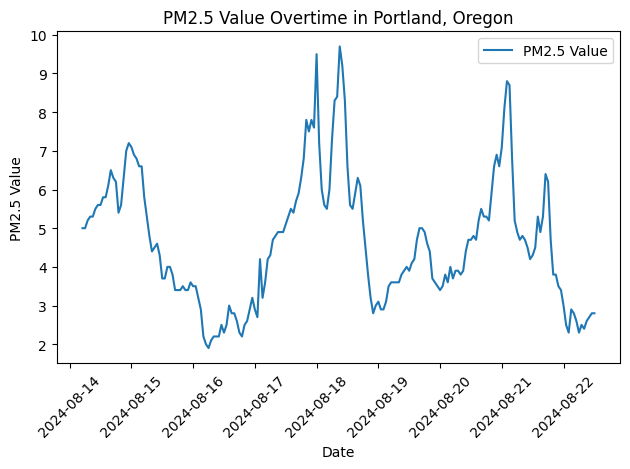

In [7]:
# visualize the time series
plt.plot(air_quality['Value'], label='PM2.5 Value')
plt.xlabel('Date')
plt.ylabel('PM2.5 Value')
plt.legend()
plt.title('PM2.5 Value Overtime in Portland, Oregon')

# rotate labels and plot data
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

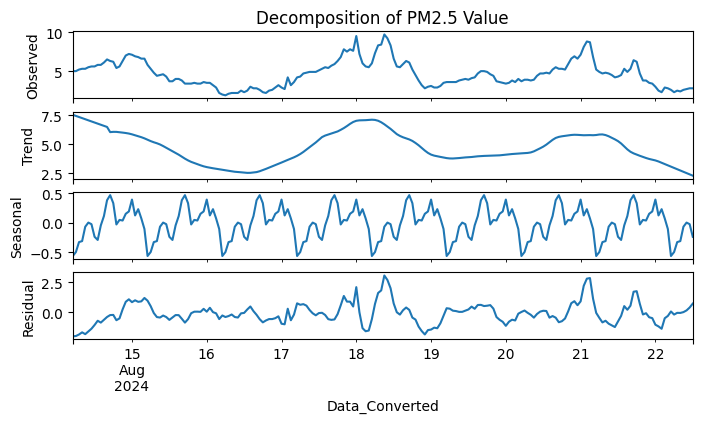

In [8]:
# check the decompositions
decomp = seasonal_decompose(air_quality['Value'], period=24, model='additive', extrapolate_trend='freq')

fig, ax = plt.subplots(ncols=1, nrows=4, sharex=True, figsize=(8,4))
ax[0].set_title('Decomposition of PM2.5 Value')
decomp.observed.plot(ax=ax[0], legend=False)
ax[0].set_ylabel('Observed')

decomp.trend.plot(ax=ax[1], legend=False)
ax[1].set_ylabel('Trend')

decomp.seasonal.plot(ax=ax[2], legend=False)
ax[2].set_ylabel('Seasonal')

decomp.resid.plot(ax=ax[3], legend=False)
ax[3].set_ylabel('Residual')

plt.show();

In [9]:
# creating "lag" features (to do the analysis manually)
for i in range(1, 11):
    air_quality[f'Lag {i}'] = air_quality['Value'].shift(i)

air_quality = air_quality.dropna()
air_quality.head()

,Value,Lag 1,Lag 2,Lag 3,Lag 4,Lag 5,Lag 6,Lag 7,Lag 8,Lag 9,Lag 10
Data_Converted,,,,,,,,,,,
2024-08-14 15:00:00,6.1,5.8,5.8,5.6,5.6,5.5,5.3,5.3,5.2,5.0,5.0
2024-08-14 16:00:00,6.5,6.1,5.8,5.8,5.6,5.6,5.5,5.3,5.3,5.2,5.0
2024-08-14 17:00:00,6.3,6.5,6.1,5.8,5.8,5.6,5.6,5.5,5.3,5.3,5.2
2024-08-14 18:00:00,6.2,6.3,6.5,6.1,5.8,5.8,5.6,5.6,5.5,5.3,5.3
2024-08-14 19:00:00,5.4,6.2,6.3,6.5,6.1,5.8,5.8,5.6,5.6,5.5,5.3


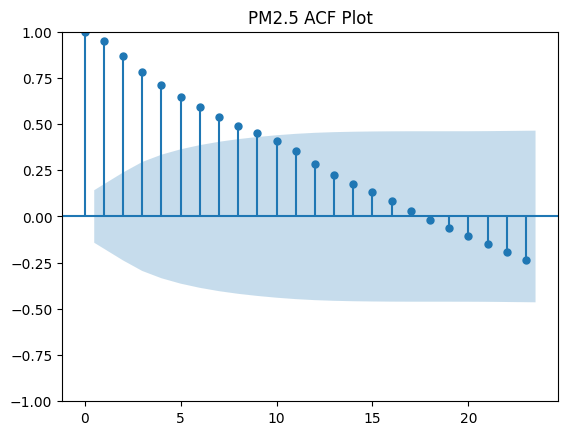

In [10]:
# ACF plot
series = air_quality['Value']
plot_acf(series, title = 'PM2.5 ACF Plot')
plt.show();

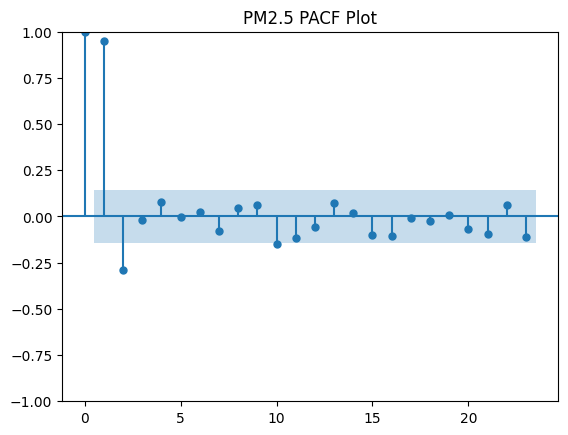

In [11]:
# PACF plot
series = air_quality['Value']
plot_pacf(series, title = 'PM2.5 PACF Plot')
plt.show();

ACF plot generally declines gradually while PACF plot cuts off quickly. This means that an AR(p) model would be more appropriate.

In [12]:
# get p-value
result = adfuller(air_quality['Value'])
print('p-value:', result[1])

p-value: 0.043884687043289995


In [13]:
# split into training and test sets (80% training and 20% testing)
train_size = int(.8 * len(air_quality))
train_data = air_quality[:train_size]
test_data = air_quality[train_size:]

# put the y feature (PM2.5) in arrays
y_train = np.array(train_data['Value']).reshape(-1,1)
y_test = np.array(test_data['Value']).reshape(-1,1)

### AR(p) Model:

In [14]:
# AR(9) model
X_train = np.array(train_data['Lag 5']).reshape(-1,1)

# add intercept
X_train = np.hstack([X_train, np.ones((X_train.shape[0], 1))])

print(X_train.shape)
print(y_train.shape)

(152, 2)
(152, 1)


In [15]:
# fit model using OLS:
w = np.dot(np.linalg.inv(np.dot(X_train.T, X_train)), np.dot(X_train.T, y_train))
w

array([[0.70723906],
       [1.36550869]])

In [16]:
# predictions
y_pred = []
start = X_train[len(X_train)-1].reshape(-1,1)
for i in range(len(y_test)):
    y_pred.append(w.T.dot(start).flatten()[0])
    start = np.vstack([y_pred[i].flatten(), 1]) # with intercept

In [17]:
# observed versus predicted
pred_data = pd.DataFrame({'Date': test_data.index, 'pred PM2.5 Value': y_pred})
pred_data.set_index('Date', inplace = True)
pred_data.head()

,pred PM2.5 Value
Date,
2024-08-20 23:00:00,5.113876
2024-08-21 00:00:00,4.982241
2024-08-21 01:00:00,4.889144
2024-08-21 02:00:00,4.823303
2024-08-21 03:00:00,4.776737


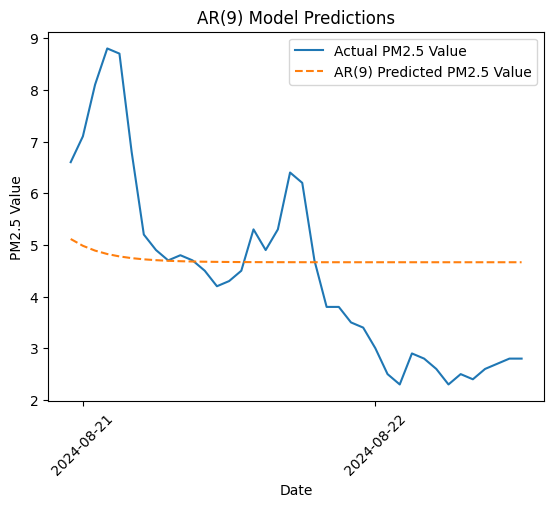

In [18]:
# plot predictions
plt.plot(test_data['Value'], label = 'Actual PM2.5 Value')
plt.plot(pred_data['pred PM2.5 Value'], label = 'AR(9) Predicted PM2.5 Value', linestyle = '--')
plt.xlabel('Date')
plt.ylabel('PM2.5 Value')
plt.legend()
plt.title('AR(9) Model Predictions')

plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=1))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))

# rotate labels
plt.xticks(rotation=45)
plt.show();

In [19]:
# calculate MAE and RMSE
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f'Mean Absolute Error: {mae:.2f}')
print(f'Root Mean Squared Error: {rmse:.2f}')

Mean Absolute Error: 1.43
Root Mean Squared Error: 1.76


### ARMA/ARIMA Model:

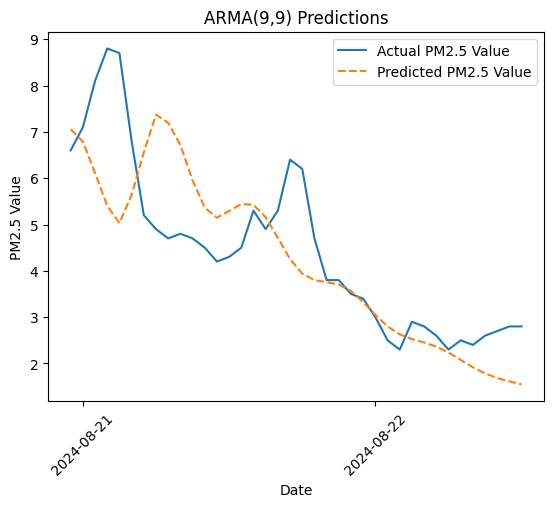

In [20]:
# ARIMA/ARMA model
def fit_arima(y_train, p, d, q):
    # compute difference (only for ARIMA model not needed for ARMA)
    y_diff = np.diff(y_train, n=1) if d > 0 else y_train

    def objective(params):
        ar_params, ma_params = params[:p], params[p:]

        # compute predicted values using AR
        ar_values = np.zeros_like(y_diff)
        for t in range(p, len(y_diff)):
          ar_values[t] = np.dot(ar_params, y_train[t-p:t][::-1])  # Using past p values
        residuals = y_diff - ar_values

        # compute predicted values using MA
        ma_values = np.zeros_like(residuals)
        for t in range(q, len(residuals)):
            ma_values[t] = np.dot(ma_params, residuals[t-q:t][::-1])

        error = residuals - ma_values
        return np.sum(error**2)

    np.random.seed(0)
    init_params = np.random.randn(p + q) * 0.1
    result = minimize(objective, init_params, method='L-BFGS-B')
    return result.x[:p], result.x[p:]

# predictions
def predict_arima(y_train, ar_params, ma_params, p, q, d, steps):
    y_diff = np.array(y_train)
    forecasts = []
    errors = [0] * q

    for _ in range(steps):
        # last p values to compute AR component
        y_values = y_diff[-p:][::-1]
        ar_part = np.dot(ar_params, y_values).item() if p else 0

        # last q errors to compute MA component
        e_values = np.array(errors[-q:][::-1])
        ma_part = np.dot(ma_params, e_values).item() if q else 0

        # forecast as scalar
        forecast = ar_part + ma_part
        forecasts.append(float(forecast))
        y_diff = np.append(y_diff, forecast)
        errors.append(float(forecast))

    return np.array(forecasts)

# fit ARMA/ARIMA model
y_train = y_train.flatten()
p, d, q = 9, 0, 9 # ARIMA(9,0,9) = ARMA(9,9)
ar_params, ma_params = fit_arima(y_train, p, d, q)

# predict values
future_predictions = predict_arima(y_train, ar_params, ma_params, p, q, d, len(y_test))

# plot predicted values
y_test_flat = y_test.flatten()
plt.plot(test_data.index, y_test_flat, label="Actual PM2.5 Value")
plt.plot(test_data.index, future_predictions, label="Predicted PM2.5 Value", linestyle="--")

plt.xlabel("Date")
plt.ylabel("PM2.5 Value")
plt.legend()
plt.title("ARMA(9,9) Predictions")

plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=1))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.xticks(rotation=45)
plt.show()

In [21]:
# calculate MAE and RMSE
mae = mean_absolute_error(y_test, future_predictions)
rmse = np.sqrt(mean_squared_error(y_test, future_predictions))
print(f'Mean Absolute Error: {mae:.2f}')
print(f'Root Mean Squared Error: {rmse:.2f}')

Mean Absolute Error: 0.99
Root Mean Squared Error: 1.36
